# Exploratory Data Analysis

## Objective 
- Examining the overall structure and distribution of the data.
- Understanding the behavior of numerical and categorical variables.
- Analyzing sales performance across different dimensions such as product categories, channels, payment methods, and customer segments.
- Exploring relationships between variables to uncover meaningful business patterns.

The insights obtained from EDA provide a foundation for deeper analysis and support data-driven decision-making.

## Importing Libraries and Data Preparation

In [1]:
#Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
#Loading Cleaned Dataset
df = pd.read_csv("../dataset/cleaned_data.csv",parse_dates=['Transaction Date'])

In [3]:
#Checking first few rows of the Dataset
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,Unknown
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


In [4]:
#Checking Dimensions of Dataset
df.shape

(11971, 11)

In [5]:
#Getting Information about the Dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11971 entries, 0 to 11970
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    11971 non-null  str           
 1   Customer ID       11971 non-null  str           
 2   Category          11971 non-null  str           
 3   Item              11971 non-null  str           
 4   Price Per Unit    11971 non-null  float64       
 5   Quantity          11971 non-null  float64       
 6   Total Spent       11971 non-null  float64       
 7   Payment Method    11971 non-null  str           
 8   Location          11971 non-null  str           
 9   Transaction Date  11971 non-null  datetime64[us]
 10  Discount Applied  11971 non-null  str           
dtypes: datetime64[us](1), float64(3), str(7)
memory usage: 1.7 MB


In [6]:
#Describing the Dataset
df.describe()

,Price Per Unit,Quantity,Total Spent,Transaction Date
count,11971.000000,11971.000000,11971.000000,11971
mean,23.360872,5.536380,129.652577,2023-07-13 02:26:23.627098
min,5.000000,1.000000,5.000000,2022-01-01 00:00:00
25%,14.000000,3.000000,51.000000,2022-09-29 00:00:00
50%,23.000000,6.000000,108.500000,2023-07-13 00:00:00
75%,33.500000,8.000000,192.000000,2024-04-24 00:00:00
max,41.000000,10.000000,410.000000,2025-01-18 00:00:00
std,10.741889,2.857883,94.750697,NaN


## Univariate Analysis

### Categorical Univariate Analysis

#### Which Product category performed the highest? 

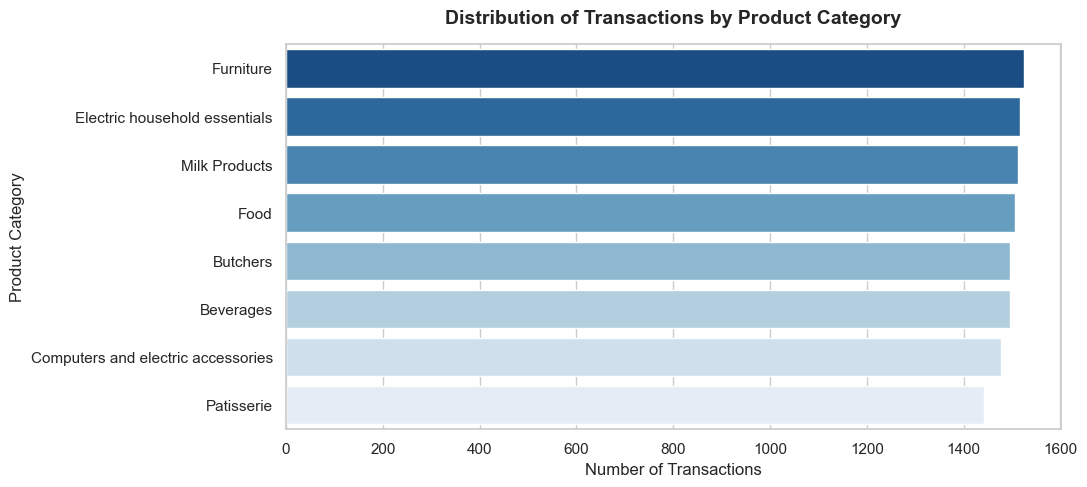

In [7]:
#Checking Distribution of Transactions by Product Category
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

category_counts = df['Category'].value_counts()
sns.barplot(x=category_counts.values, y=category_counts.index, palette="Blues_r")

plt.title('Distribution of Transactions by Product Category', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Transactions', fontsize=12)
plt.ylabel('Product Category', fontsize=12)

plt.show()

**Furniture** is the highest-performing category by total transaction volume, dominating the dataset.

**Patisserie** represents the lowest-performing category, indicating a potential area for operational growth or marketing focus.

#### Which Payment Method was most preferred by Customers?

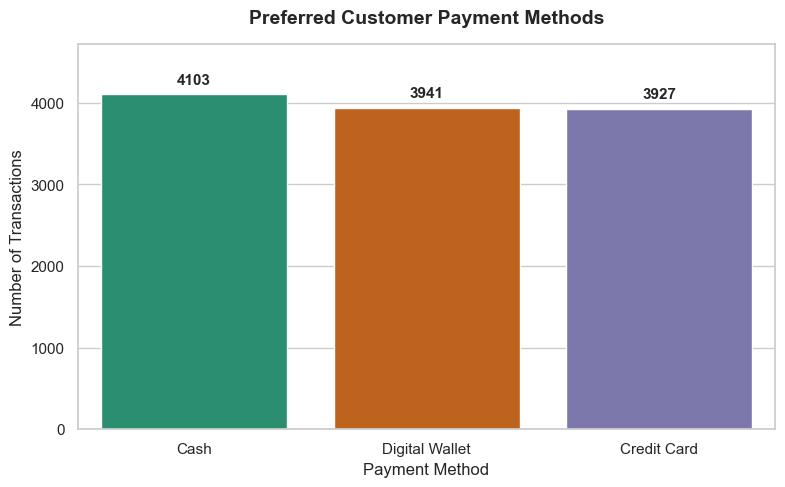

In [8]:
#Checking the Preferred Payment Method by Customers
plt.figure(figsize=(9, 5))

payment_counts = df['Payment Method'].value_counts()

ax = sns.barplot(x=payment_counts.index, y=payment_counts.values, palette="Dark2")

for container in ax.containers:
    ax.bar_label(container, fmt='%1.0f', padding=5, fontsize=11, fontweight='bold')
    
plt.ylim(0, payment_counts.max() * 1.15)

plt.title('Preferred Customer Payment Methods', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Payment Method', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)

plt.show()

* **Cash** is the most preferred payment method among customers, accounting for 4,103 transactions.
* **Digital Wallets** (3,941) slightly outperform **Credit Cards** (3,927), though the split between these two digital methods is highly competitive, separated by a margin of just 14 transactions.

#### Which Sales Location has the most Transactions?

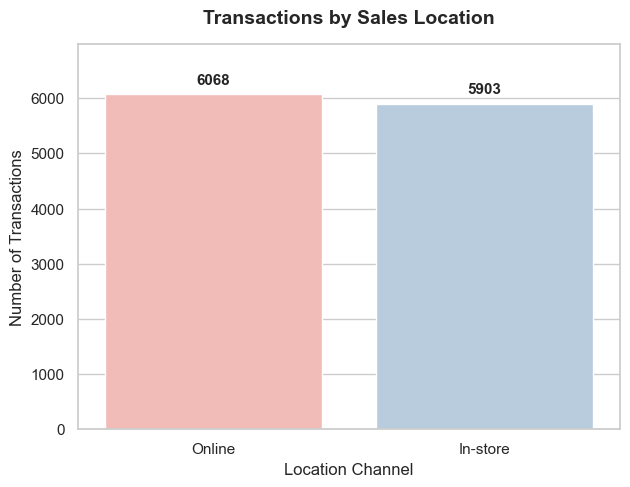

In [9]:
#Checking Transactions by Sales Location
plt.figure(figsize=(7, 5))
 
location_df = df['Location'].value_counts().reset_index()
location_df.columns = ['Location', 'Transaction Count']
 
ax = sns.barplot(data=location_df, x='Location', y='Transaction Count', palette="Pastel1")

for container in ax.containers:
    ax.bar_label(container, fmt='%1.0f', padding=5, fontsize=11, fontweight='bold')

plt.ylim(0, location_df['Transaction Count'].max() * 1.15)

plt.title('Transactions by Sales Location', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Location Channel', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)

plt.show()

* The business maintains a highly balanced omnichannel distribution, with **Online** transactions (6,068) slightly edgeing out **In-Store** transactions (5,903). 
* This close split suggests a strong digital presence alongside a consistently active physical retail footprint.

#### How many Customers got Discount?

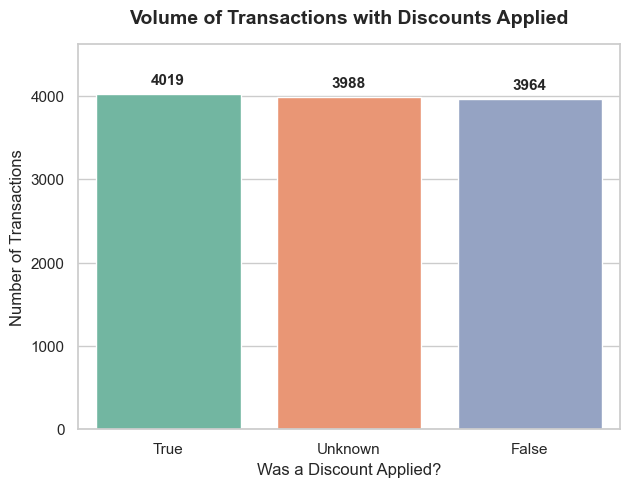

In [10]:
#Checking The Volume of Transactions with Discount Applied
plt.figure(figsize=(7, 5))

discount_df = df['Discount Applied'].value_counts().reset_index()
discount_df.columns = ['Discount Applied', 'Transaction Count']

ax = sns.barplot(data=discount_df, x='Discount Applied', y='Transaction Count', palette="Set2")

for container in ax.containers:
    ax.bar_label(container, fmt='%1.0f', padding=5, fontsize=11, fontweight='bold')

plt.ylim(0, discount_df['Transaction Count'].max() * 1.15)

plt.title('Volume of Transactions with Discounts Applied', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Was a Discount Applied?', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)

plt.show()

* **Discount Applied (True):** 4,019 transactions.
* **No Discount (False):** 3,964 transactions.
* **Imputed Data (Unknown):** 3,988 transactions were originally missing and filled as 'Unknown' during the data cleaning phase.
* **Strategic Note:** Because the data is almost perfectly split into thirds, we must be careful when running bivariate analysis later to see how 'Unknown' columns behave compared to known True/False discount columns.

### Numerical Univariate Analysis

#### Distributions of Numerical Columns

count    11971.000000
mean        23.360872
std         10.741889
min          5.000000
25%         14.000000
50%         23.000000
75%         33.500000
max         41.000000
Name: Price Per Unit, dtype: float64


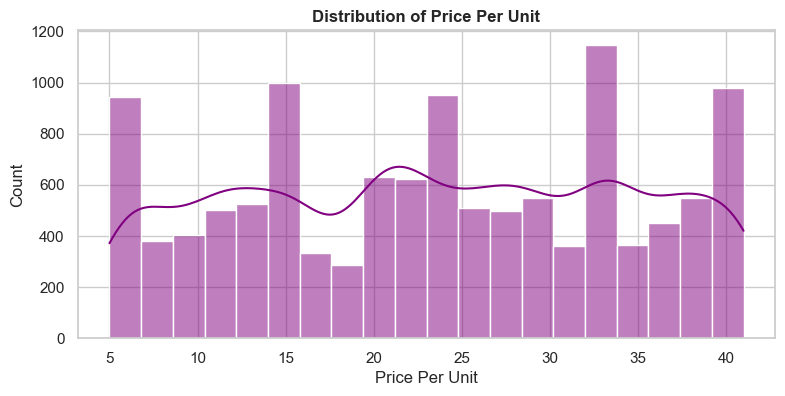

In [11]:
#Distribution of Price Per Unit Column
ppu = df['Price Per Unit'].describe()
print(ppu)

#Plotting histogram
plt.figure(figsize=(9, 4))
sns.histplot(data=df, x='Price Per Unit', bins=20, kde=True, color='purple')
plt.title('Distribution of Price Per Unit', fontweight='bold')
plt.show()

**Key Observations:**
* **Range & Center:** Product prices are strictly bounded between a minimum of **$5.00** and a maximum of **$41.00**, with a median value (50%) of **$23.00**.
* **Distribution Shape:** The mean ($23.36) and the median ($23.00) are almost identical. This indicates that the item prices are distributed remarkably evenly across the entire stock inventory without extreme skewness.

count    11971.000000
mean         5.536380
std          2.857883
min          1.000000
25%          3.000000
50%          6.000000
75%          8.000000
max         10.000000
Name: Quantity, dtype: float64


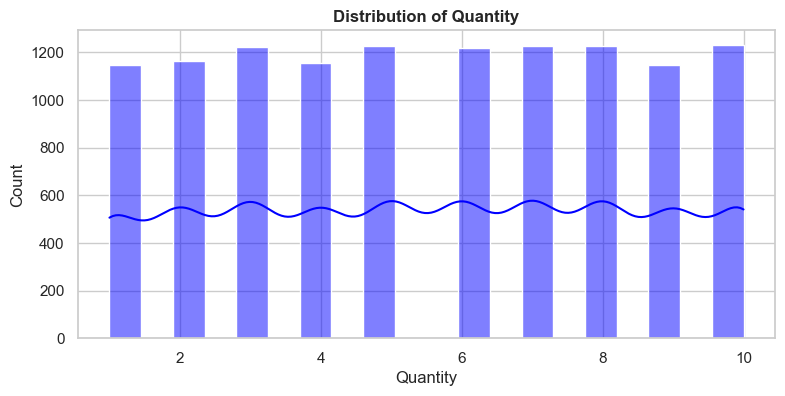

In [12]:
#Distribution of Quantity Column
quantity = df['Quantity'].describe()
print(quantity)

#Plotting Histogram
plt.figure(figsize=(9, 4))
sns.histplot(data=df, x='Quantity', bins=20, kde=True, color='blue')
plt.title('Distribution of Quantity', fontweight='bold')
plt.show()

**Key Observations:**
* **Range & Center:** Customers purchase anywhere from a minimum of **1 item** to a maximum bulk order of **10 items** per transaction, with the average order size sitting right at **~5.5 items**.
* **Distribution Shape:** The uniform gap between the quartiles (25% at 3 items, 50% at 6 items, and 75% at 8 items) shows a very balanced shopping behavior—bulk orders of 9-10 items occur just as predictably as smaller single-digit purchases.

count    11971.000000
mean       129.652577
std         94.750697
min          5.000000
25%         51.000000
50%        108.500000
75%        192.000000
max        410.000000
Name: Total Spent, dtype: float64


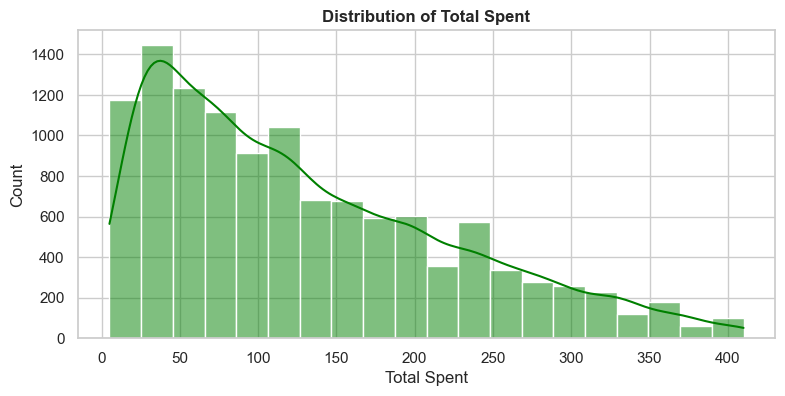

In [13]:
#Distribution of Total Spent Column
ts = df['Total Spent'].describe()
print(ts)

#Plotting Histogram
plt.figure(figsize=(9, 4))
sns.histplot(data=df, x='Total Spent', bins=20, kde=True, color='green')
plt.title('Distribution of Total Spent', fontweight='bold')
plt.show()

**Key Observations:**
* **Range & Center:** The total revenue generated per invoice ranges from a minimum pocket-change transaction of **$5.00** up to a high-value order of **$410.00**. The typical midpoint transaction (median) is **$108.50**.
* **Distribution Shape & Skewness:** Unlike the previous columns, this data shows a clear **Right-Skew (Positive Skew)**. The mean ($129.65) is noticeably higher than the median ($108.50). 
* **Strategic Note:** The long tail stretching toward the $410 maximum represents our high-value cart checkouts. While the majority of customers spend closer to $50–$150, these premium transactions pull our mathematical average upward—a vital dynamic to remember as we transition into Bivariate Analysis.

## Bivariate Analysis

#### Which product category has the highest average transaction value?

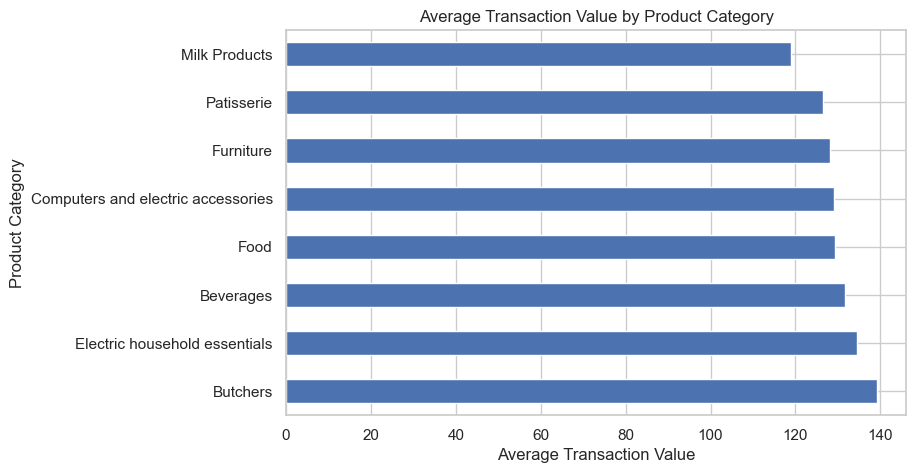

In [14]:
avg_transaction = (
    df.groupby('Category')['Total Spent']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
avg_transaction.plot(kind='barh')

plt.xlabel('Average Transaction Value')
plt.ylabel('Product Category')
plt.title('Average Transaction Value by Product Category')

plt.show()

**Key Observations:**

* **Highest Transaction Value:** The **Butchers** category recorded the highest average transaction value, indicating that customers tend to spend more per purchase in this category.

* **Lowest Transaction Value:** In contrast, **Milk Products** exhibited the lowest average transaction value, reflecting relatively smaller spending amounts per transaction.

* **Business Insight:** These differences suggest that customer spending behavior varies across product categories, highlighting opportunities for category-specific pricing and promotional strategies.

#### Which sales channel (Online or In-Store) generates higher revenue?

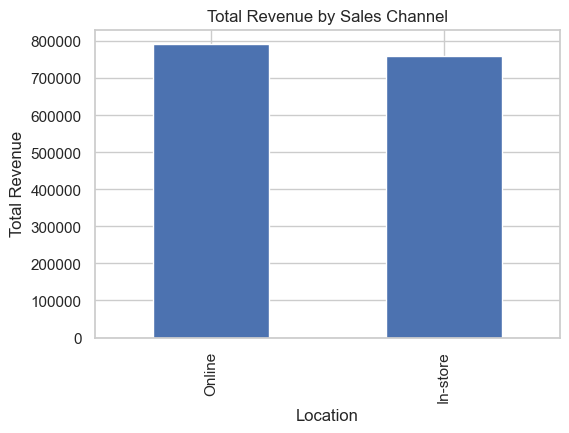

In [15]:
revenue_by_location = (
    df.groupby('Location')['Total Spent']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(6,4))

revenue_by_location.plot(kind='bar')

plt.xlabel('Location')
plt.ylabel('Total Revenue')
plt.title('Total Revenue by Sales Channel')

plt.show()

**Key Observations:**

* **Higher Revenue Channel:** The **Online** channel generated the highest revenue, approaching ₹8 lakh, indicating slightly stronger sales performance compared to physical stores.

* **In-Store Performance:** The **In-Store** channel also contributed significantly, generating revenue between ₹7–8 lakh, reflecting a relatively balanced distribution across both sales channels.

* **Business Insight:** The results suggest that while both channels are important revenue drivers, the Online channel holds a slight advantage and may offer opportunities for further growth through digital sales initiatives.

#### Which year generated the most revenue?

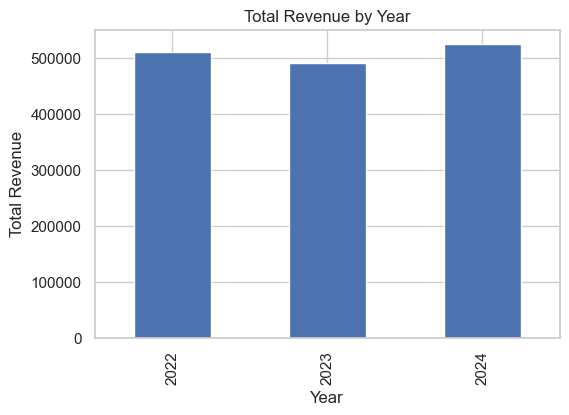

In [16]:
revenue_by_year = (
    df[df['Transaction Date'].dt.year < 2025]
    .groupby(df['Transaction Date'].dt.year)['Total Spent']
    .sum()
)

plt.figure(figsize=(6,4))

revenue_by_year.plot(kind='bar')

plt.xlabel('Year')
plt.ylabel('Total Revenue')
plt.title('Total Revenue by Year')

plt.show()

**Key Observations:**

* **Highest Revenue Year:** **2024** generated the highest revenue, outperforming the previous years and demonstrating the strongest sales performance in the dataset.

* **Revenue Trend:** Annual revenue exhibited an overall upward pattern, with 2024 emerging as the dominant year.

* **Business Insight:** The increase in revenue over time suggests improving sales performance and may indicate growing customer demand or business expansion. Data for 2025 was excluded from the analysis because it only contains transactions up to **18 January 2025**, making year-over-year comparisons unreliable.


#### Which product category has the highest average price per unit?

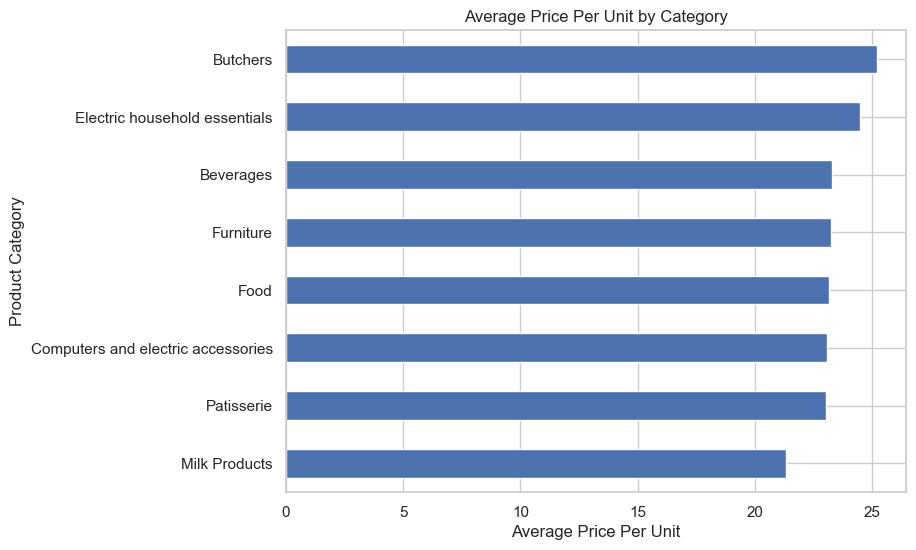

In [17]:
avg_price = (
    df.groupby('Category')['Price Per Unit']
    .mean()
    .sort_values(ascending=True)
)

plt.figure(figsize=(8,6))

avg_price.plot(kind='barh')

plt.xlabel('Average Price Per Unit')
plt.ylabel('Product Category')
plt.title('Average Price Per Unit by Category')

plt.show()

**Key Observations:**

* **Highest Average Price:** **Butchers** recorded the highest average price per unit, whereas **Milk Products** had the lowest.

* **Pricing Pattern:** The pricing hierarchy broadly aligns with the average transaction value analysis, indicating that categories with higher-priced products also tend to generate larger transaction values.

* **Business Insight:** Differences among the middle categories suggest that transaction values are influenced not only by product prices but also by the quantities purchased.


#### Does purchasing larger quantities lead to higher transaction values?

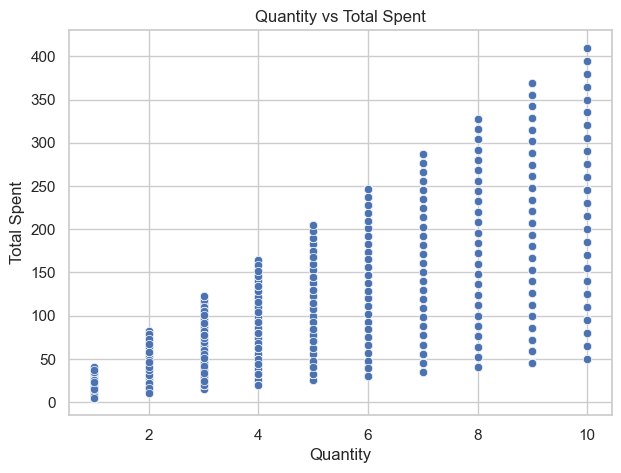

In [18]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x='Quantity',
    y='Total Spent'
)

plt.xlabel('Quantity')
plt.ylabel('Total Spent')
plt.title('Quantity vs Total Spent')

plt.show()

**Key Observations:**

* **Positive Relationship:** The scatter plot reveals a clear positive relationship between **Quantity** and **Total Spent**. As the number of units purchased increases, the transaction value tends to rise as well.

* **Pattern:** The upward alignment of data points indicates that larger purchases are generally associated with higher spending, suggesting a noticeable correlation between the two variables.

* **Business Insight:** Quantity plays a significant role in determining transaction value, implying that encouraging customers to purchase more items could contribute to higher revenue.


#### Correlation Matrix

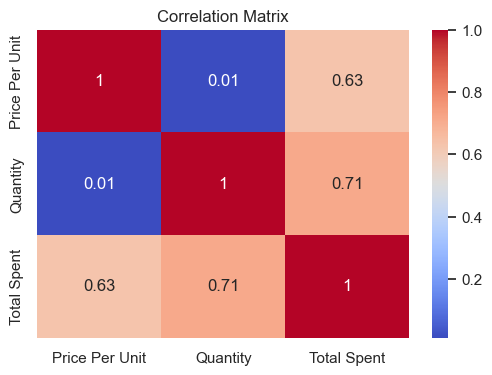

In [19]:
numerical_cols = ['Price Per Unit', 'Quantity', 'Total Spent']

plt.figure(figsize=(6,4))

sns.heatmap(
    df[numerical_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')

plt.show()

**Key Observations:**

* **Strongest Relationship:** **Quantity** and **Total Spent** exhibit the strongest positive correlation (**0.71**), indicating that larger purchases are generally associated with higher transaction values.

* **Moderate Relationship:** **Price Per Unit** shows a moderate positive correlation (**0.63**) with **Total Spent**, suggesting that higher-priced products tend to contribute to larger bills, although the relationship is not as strong as that of quantity.

* **Minimal Relationship:** The correlation between **Price Per Unit** and **Quantity** is nearly zero (**0.01**), implying that the number of items purchased is largely independent of their prices.

* **Business Insight:** Overall, transaction value is influenced by both product pricing and purchase quantity, with quantity having a slightly greater impact. Furthermore, customers do not appear to systematically purchase fewer units of higher-priced products.


## Multivariate Analysis

#### Which product categories generate the highest revenue in each sales channel?

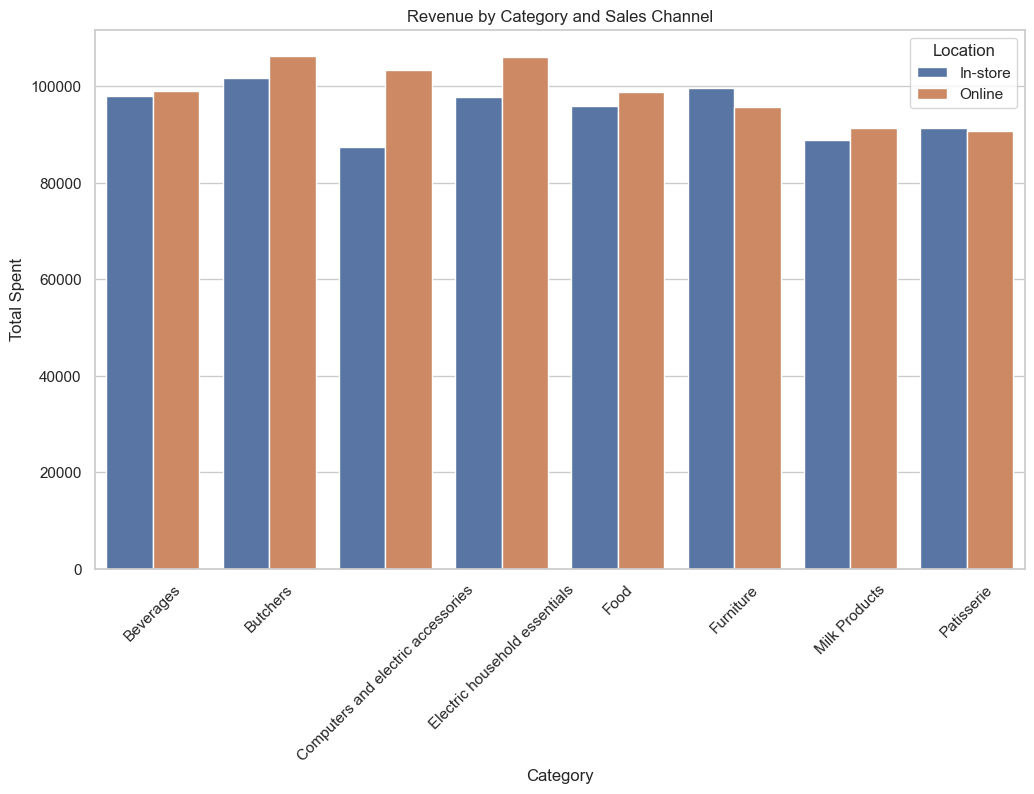

In [20]:
revenue = (
    df.groupby(['Category', 'Location'])['Total Spent']
    .sum()
    .reset_index()
)

plt.figure(figsize=(12,7))

sns.barplot(
    data=revenue,
    x='Category',
    y='Total Spent',
    hue='Location'
)

plt.xticks(rotation=45)
plt.title('Revenue by Category and Sales Channel')

plt.show()

**Key Observations:**

* **Channel Performance:** **Butchers** generated the highest revenue in the **Offline** channel, while **Butchers** and **Electric Household Essentials** emerged as the leading revenue contributors in the **Online** channel.

* **Pattern:** Despite differences in sales channels, the same categories consistently appear among the top performers, indicating stable demand across channels.

* **Business Insight:** Premium categories maintain strong revenue generation regardless of where customers shop, suggesting that channel preference has a limited impact on the performance of leading categories.


#### Which categories have the highest average transaction value for each payment method?

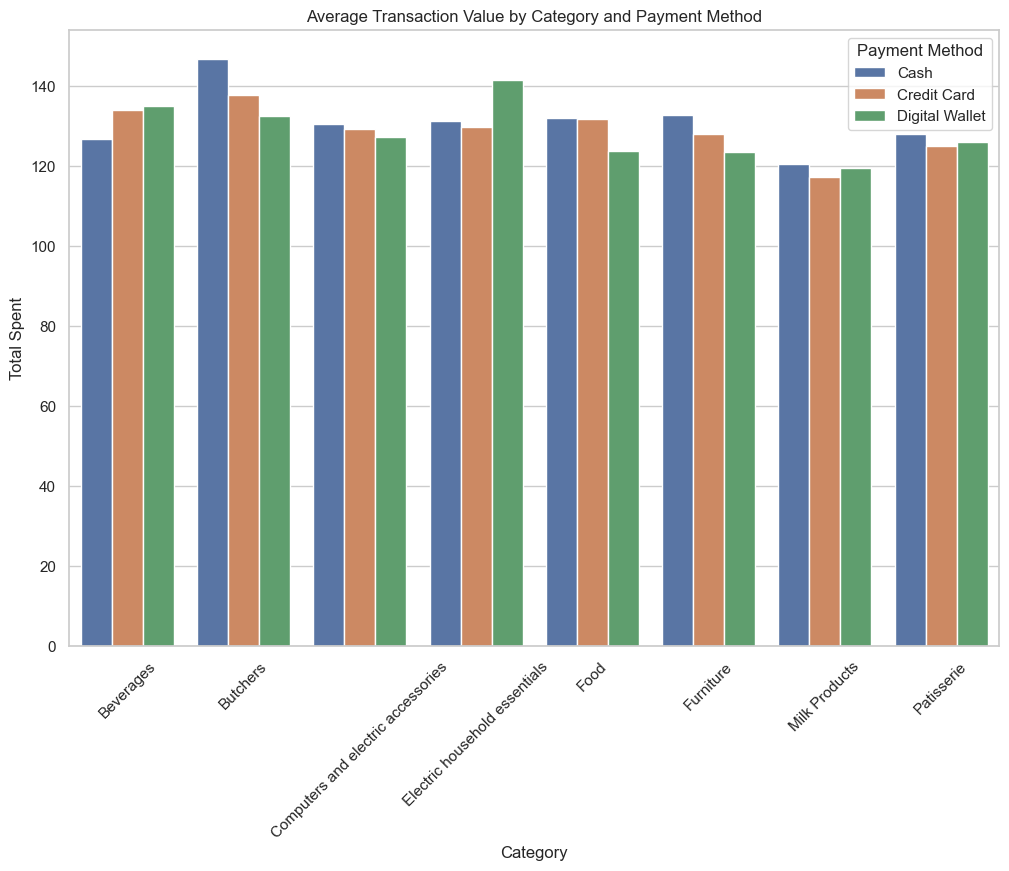

In [21]:
avg_spent = (
    df.groupby(['Category', 'Payment Method'])['Total Spent']
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,8))

sns.barplot(
    data=avg_spent,
    x='Category',
    y='Total Spent',
    hue='Payment Method'
)

plt.xticks(rotation=45)
plt.title('Average Transaction Value by Category and Payment Method')

plt.show()

**Key Observations:**

* **Highest Average Transaction Value:** **Butchers** recorded the highest average transaction value for transactions made through **Cash** and **Credit Cards**, whereas **Electric Household Essentials** led among **Digital Wallet** users.

* **Pattern:** The leading categories vary slightly across payment methods, indicating that customer spending behavior remains broadly consistent regardless of the mode of payment.

* **Business Insight:** Payment methods do not appear to significantly alter purchasing patterns, as high-value categories continue to dominate across different transaction types.


#### Which product categories have the highest average price per unit across sales channels?

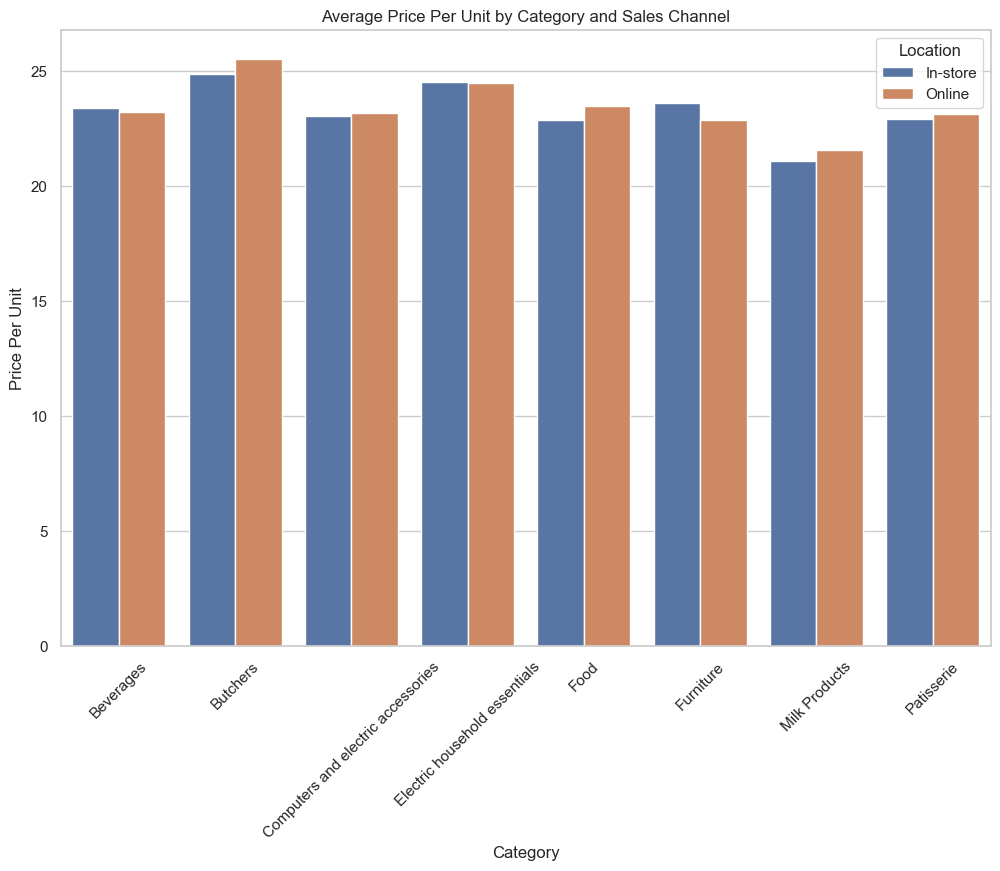

In [22]:
avg_price = (
    df.groupby(['Category', 'Location'])['Price Per Unit']
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,8))

sns.barplot(
    data=avg_price,
    x='Category',
    y='Price Per Unit',
    hue='Location'
)

plt.xticks(rotation=45)
plt.title('Average Price Per Unit by Category and Sales Channel')

plt.show()

**Key Observations:**

* **Highest Average Prices:** **Butchers** and **Electric Household Essentials** recorded the highest average price per unit across both Online and Offline channels.

* **Pricing Pattern:** The consistency of these categories across sales channels suggests that pricing structures remain relatively stable regardless of where purchases are made.

* **Business Insight:** The repeated appearance of these categories throughout the analysis highlights their premium nature, indicating that they play a significant role in driving transaction values and overall revenue.


## Summary

This Exploratory Data Analysis (EDA) examined customer transactions across product categories, payment methods, sales channels, and time periods to uncover patterns influencing revenue and purchasing behavior.

Key findings include:

* **Butchers** and **Electric Household Essentials** consistently emerged as high-performing categories across multiple analyses.
* **Online** and **In-Store** channels generated comparable revenues, indicating balanced customer preferences between channels.
* **2024** recorded the highest revenue among all years, while the lower revenue observed in 2025 is attributable to incomplete data availability.
* A strong positive relationship was observed between **Quantity** and **Total Spent**, highlighting the importance of purchase volume in driving transaction values.
* The correlation analysis revealed that transaction values are influenced by both product prices and quantities, with quantity having a slightly stronger impact.
* Most categorical combinations exhibited minimal differences, suggesting relatively stable customer behavior across channels and payment methods.
* Multivariate analysis reinforced that premium categories consistently contribute more to revenue and average transaction values, regardless of sales channel or payment method.


## Conclusion

The analysis indicates that revenue generation is primarily driven by a few premium product categories, particularly **Butchers** and **Electric Household Essentials**, which repeatedly demonstrated strong performance across various dimensions of the dataset.

Customer behavior appears to be relatively balanced across sales channels and payment methods, with no substantial segmentation patterns observed. Furthermore, larger purchase quantities are associated with higher transaction values, emphasizing the role of purchase volume in overall revenue generation.

Overall, the dataset reflects stable purchasing patterns and highlights the importance of premium categories in sustaining business performance. These insights can support future decision-making related to product strategy, pricing, and sales channel management.
